In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df['job_type_skills'] = df['job_type_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else {})

In [2]:
df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_da_us = df_da_us.dropna(subset='salary_year_avg')

df_da_us_exploded = df_da_us.explode('job_skills')

df_da_us_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [3]:
df_da_us_skills = df_da_us_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_da_us_skills = df_da_us_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
df_da_us_count = len(df_da_us)
df_da_us_skills['skill_percent'] = df_da_us_skills['skill_count'] / df_da_us_count * 100
df_da_us_skills = df_da_us_skills[df_da_us_skills['skill_count'] > 0].round(0)
df_da_us_skills



,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,58.0
excel,1808,84392.0,42.0
python,1431,97500.0,33.0
tableau,1364,92875.0,31.0
sas,926,90000.0,21.0
...,...,...,...
couchbase,1,160515.0,0.0
chainer,1,100000.0,0.0
chef,1,85000.0,0.0


In [4]:
skill_limit = 5

df_da_us_skills_high_demand = df_da_us_skills[df_da_us_skills['skill_percent'] > skill_limit]
df_da_us_skills_high_demand

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,58.0
excel,1808,84392.0,42.0
python,1431,97500.0,33.0
tableau,1364,92875.0,31.0
sas,926,90000.0,21.0
r,893,92500.0,21.0
power bi,838,90000.0,19.0
powerpoint,462,85000.0,11.0
word,461,81195.0,11.0


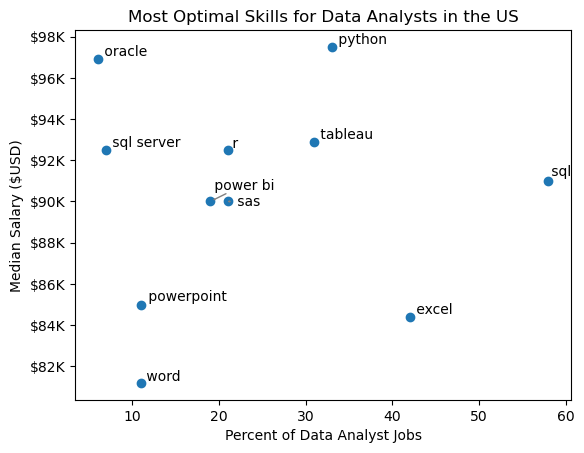

In [5]:
from adjustText import adjust_text

plt.scatter(df_da_us_skills_high_demand['skill_percent'], df_da_us_skills_high_demand['median_salary'])
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')  # Assuming this is the label you want for y-axis
plt.title('Most Optimal Skills for Data Analysts in the US')

# Get current axes, set limits, and format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis

# Add labels to points and collect them in a list
texts = []
for i, txt in enumerate(df_da_us_skills_high_demand.index):
    texts.append(plt.text(df_da_us_skills_high_demand['skill_percent'].iloc[i], df_da_us_skills_high_demand['median_salary'].iloc[i], " " + txt))

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()

In [12]:
df_technology = df[['job_type_skills', 'job_skills']].copy()
df_technology = df_technology.explode('job_type_skills')
df_technology = df_technology.explode('job_skills')

df_technology = df_technology.dropna(subset=['job_skills', 'job_type_skills'])

# ✅ FIX: get most frequent category per skill
df_technology = (
            df_technology.groupby(['job_skills', 'job_type_skills'])
            .size()
            .reset_index(name='count')
        )
# Keep dominant category
df_technology = df_technology.sort_values('count', ascending=False)
df_technology = df_technology.drop_duplicates(subset='job_skills')

#df_technology = df_technology.drop_duplicates(subset='job_skills').dropna(subset='job_skills')
#df_technology = df_technology.drop_duplicates(subset='job_type_skills').dropna(subset='job_type_skills')
df_technology

,job_skills,job_type_skills,count
1946,sql,programming,384849
1590,python,programming,380909
147,aws,cloud,145381
157,azure,cloud,132527
1629,r,programming,130892
...,...,...,...
488,dingtalk,analyst_tools,1
834,gtx,programming,1
1217,msaccess,analyst_tools,1
2258,visualbasic,webframeworks,1


In [13]:
df_da_us_tech = df_da_us_skills.merge(df_technology, on='job_skills', how='left')
#df_da_us_tech = df_da_us_tech.explode('job_type_skills')
df_da_us_tech_high_demand = df_da_us_tech[df_da_us_tech['skill_percent'] > 5]
df_da_us_tech_high_demand

,job_skills,skill_count,median_salary,skill_percent,job_type_skills,count
0,sql,2508,91000.0,58.0,programming,384849
1,excel,1808,84392.0,42.0,analyst_tools,127018
2,python,1431,97500.0,33.0,programming,380909
3,tableau,1364,92875.0,31.0,analyst_tools,127213
4,sas,926,90000.0,21.0,analyst_tools,83404
5,r,893,92500.0,21.0,programming,130892
6,power bi,838,90000.0,19.0,analyst_tools,98147
7,powerpoint,462,85000.0,11.0,analyst_tools,28560
8,word,461,81195.0,11.0,analyst_tools,30572
9,sql server,286,92500.0,7.0,programming,40197


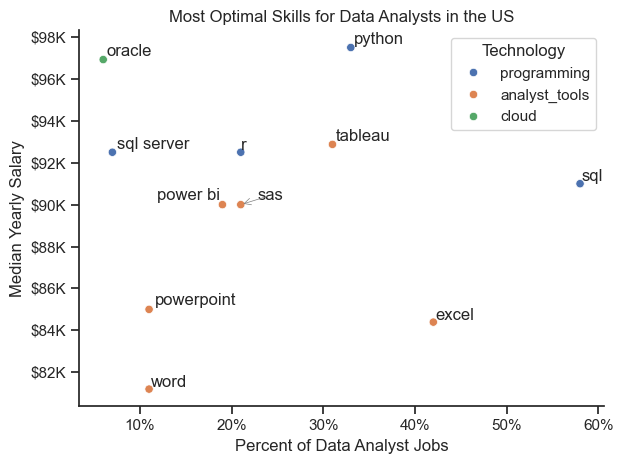

In [14]:
sns.scatterplot(
    data=df_da_us_tech_high_demand,
    x='skill_percent',
    y='median_salary',
    hue='job_type_skills'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_da_us_tech_high_demand['job_skills']):
    texts.append(plt.text(df_da_us_tech_high_demand['skill_percent'].iloc[i], df_da_us_tech_high_demand['median_salary'].iloc[i], txt))

# Adjust text to avoid overlap
#adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))
adjust_text(
    texts,
    expand_points=(3, 3),
    expand_text=(3, 3),
    force_text=10,
    force_points=3,
    lim=200,   # more iterations
    only_move={'points': 'y', 'text': 'xy'},  # allow free movement
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5)
)

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()